# GPFA-SSM (shared-only, no delay)

> **Engine class: SSM-GP** - `mbrila.GPFA` runs through `KalmanEMEngine`, the SSM (AR(P) approximation) path. **This is NOT the classical Yu et al. 2009 dense GPFA** - that is the dense-GP DLAG path with no delay (would route through `ExactEMEngine`). Naming kept for familiarity.


Fits `mbrila.GPFA` - multi-region Gaussian Process Factor Analysis (Yu et al. 2009). All latents are **shared** across regions ($n_\text{within} = 0$ is enforced) and there is no inter-region delay (`NoDelay`).

Scenario: same 5-region multi-region setup as `demo_dlag_ssm.ipynb` but with `n_within = 0` (shared-only).

See `examples/demo_gpfa_ssm.py` for the CLI equivalent.

## Setup

In [1]:
# Bootstrap: locate ``notebooks/nb_helpers.py`` (one dir up) and add
# ``examples/synthetic/`` to sys.path so ``import demo_common`` works.
import sys
from pathlib import Path

_NB_ROOT = Path.cwd()
while _NB_ROOT.name != "notebooks" and _NB_ROOT.parent != _NB_ROOT:
    _NB_ROOT = _NB_ROOT.parent
sys.path.insert(0, str(_NB_ROOT))

import nb_helpers as nb

nb.add_examples_to_path()

import demo_common as demo
import numpy as np
import torch
from mbrila import GPFA, KalmanEMEngine, LatentSpec, MOSEKernel
from mbrila.synthetic.multiregion import MultiRegionScenario

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device = {device}")

using device = cuda


## Scenario

No-delay scenario (`delay_amplitude = 0`) and `n_within = 0` (GPFA is shared-only).

In [2]:
n_trials, T, n_regions = 50, 200, 5
y_dim_per_region, n_across, n_within = 100, 2, 0
sigma_across, sigma_within = 0.05, 0.05
per_latent_sigma_ratio = 10.0

scenario = MultiRegionScenario(
    n_trials=n_trials,
    T=T,
    y_dims=tuple([y_dim_per_region] * n_regions),
    n_across=n_across,
    n_within=n_within,
    lag_across=2,
    lag_within=1,  # unused (no within latents)
    sigma_across=sigma_across,
    sigma_within=sigma_within,
    delay_shape="constant",
    delay_amplitude=0.0,
    per_latent_sigma_across=tuple(
        sigma_across * (per_latent_sigma_ratio ** (k / max(n_across - 1, 1))) for k in range(n_across)
    ),
    snr=20.0,
    seed=0,
    dtype=torch.float64,
    device="cpu",
)

data, truth = demo.sample_scenario(scenario, device=device)
print(
    f"data.y shape = {tuple(data.y.shape)}\n"
    f"truth['delay'] shape = {truth['delay'].shape}\n"
    f"truth['observable'] shape = {truth['observable'].shape}"
)

data.y shape = (50, 200, 500)
truth['delay'] shape = (200, 4, 2)
truth['observable'] shape = (50, 200, 10)


## Build & fit model

In [3]:
spec = LatentSpec(
    n_across=n_across,
    n_within=(0,) * n_regions,
)
engine = KalmanEMEngine(
    lr=1e-2,
    lr_min=1e-3,
    weight_decay=1e-2,
    log_every=25,
)
init_sigma = 0.1  # neither matches truth latent Ï
model = GPFA(
    latent_spec=spec,
    y_dims=scenario.y_dims,
    T=scenario.T,
    kernel_factory_across=lambda: MOSEKernel(num_regions=n_regions, init_sigma=init_sigma),
    engine=engine,
    device=device,
    dtype=torch.float64,
).to(device)

# pCCA emission init via the demo_common helper (GPFA doesn't ship its own
# initialize_from_data).
demo.init_linear_observation_pcca(model, data, n_across=n_across, n_within=0)

result = model.fit(data, max_iter=300, tol=1e-8)
print(f"fit done: {result.n_iter} iters, wall = {result.wall_time_s:.1f}s")

[kalman_em] iter 25/300  E_q[log p(x,y)] = 1912509.449


[kalman_em] iter 50/300  E_q[log p(x,y)] = 1920072.199


[kalman_em] iter 75/300  E_q[log p(x,y)] = 1920155.518


[kalman_em] iter 100/300  E_q[log p(x,y)] = 1919138.812


[kalman_em] iter 125/300  E_q[log p(x,y)] = 1917651.679


...

[kalman_em] iter 225/300  E_q[log p(x,y)] = 1908156.139


[kalman_em] iter 250/300  E_q[log p(x,y)] = 1906296.645


[kalman_em] iter 275/300  E_q[log p(x,y)] = 1904850.258


[kalman_em] iter 300/300  E_q[log p(x,y)] = 1903642.201


fit done: 300 iters, wall = 285.3s


## Extract fitted quantities

GPFA's delay is identically zero (NoDelay), so `pair_rmse` simply compares two zero tensors - included for layout consistency with other notebooks.

In [4]:
fitted_delay = demo.extract_delay(model, scenario.T)
fitted_obs = demo.extract_observable(model, data)
fitted_y = demo.extract_y_recon(model, data)

fitted_obs_aligned, fitted_delay_aligned, perm = nb.align_and_repermute(
    truth["observable"],
    fitted_obs,
    fitted_delay,
    n_regions=n_regions,
    n_across=n_across,
    n_within=n_within,
)
delay_rmse = demo.pair_rmse(fitted_delay_aligned, truth["delay"], n_regions)
print(f"across-latent permutation (truth -> fit slot) = {perm}")
print(f"delay_rmse after alignment = {delay_rmse:.4f} bins")

across-latent permutation (truth -> fit slot) = (1, 0)
delay_rmse after alignment = 0.0000 bins


## Figure 1 - Convergence

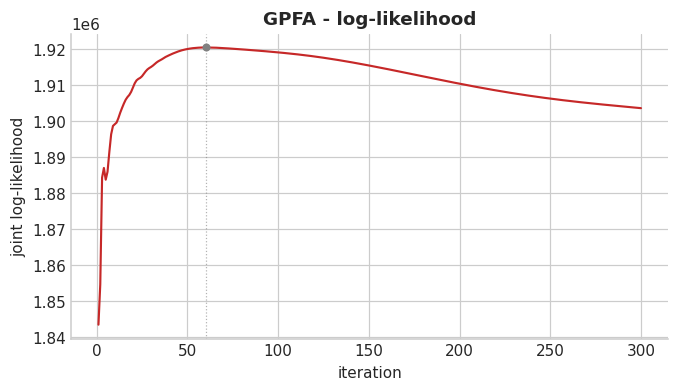

In [5]:
_ = nb.plot_convergence(np.asarray(result.score_trace, dtype=float), title="GPFA - log-likelihood")

## Figure 3 - Per-latent traces (trial 0)

One panel per `(latent, region)`. Truth dashed, fit solid (sign-aligned per panel).

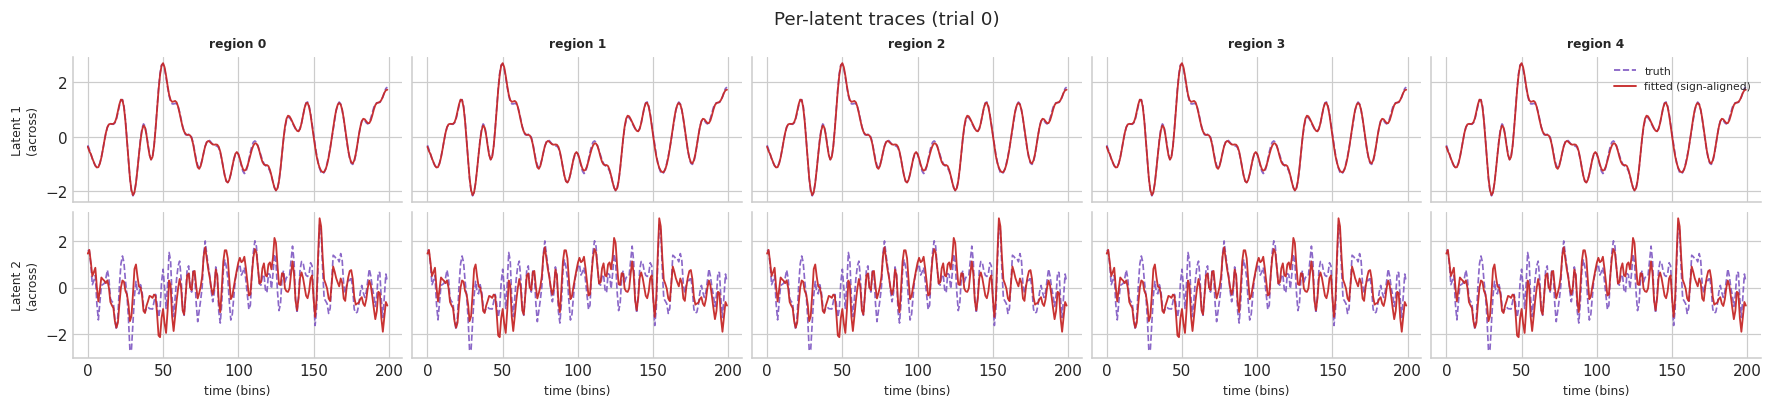

In [6]:
_ = nb.plot_latent_comparison(
    truth["observable"],
    fitted_obs_aligned,
    n_regions=n_regions,
    n_across=n_across,
    n_within=n_within,
    trial=0,
)

## Figure 4 - PSTH matrix comparison

Trial-averaged $y$ -> neuron-by-time heatmap. Three panels: truth | fitted | $\text{fitted} - \text{truth}$. Neurons in natural region-grouped order; horizontal lines mark region boundaries; divergent `RdBu_r` colormap centred at 0.

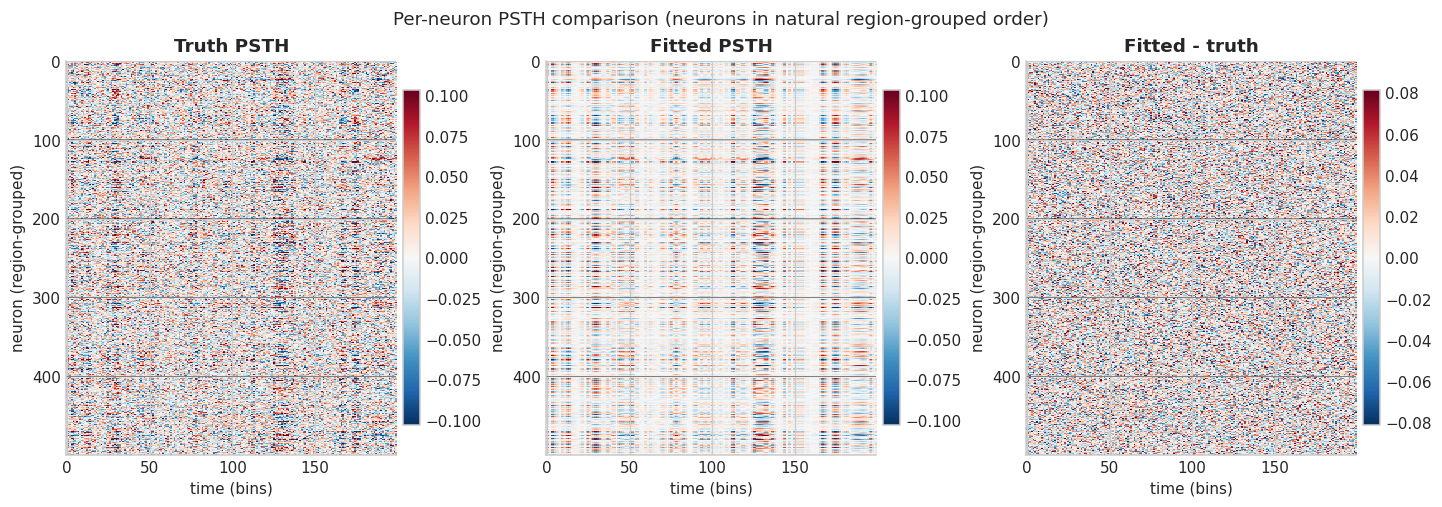

In [7]:
_ = nb.plot_psth_matrix(
    truth["y"],
    fitted_y,
    y_dims=scenario.y_dims,
)

## Figure 5 - Trial-0 reconstruction (top-variance neurons per region)

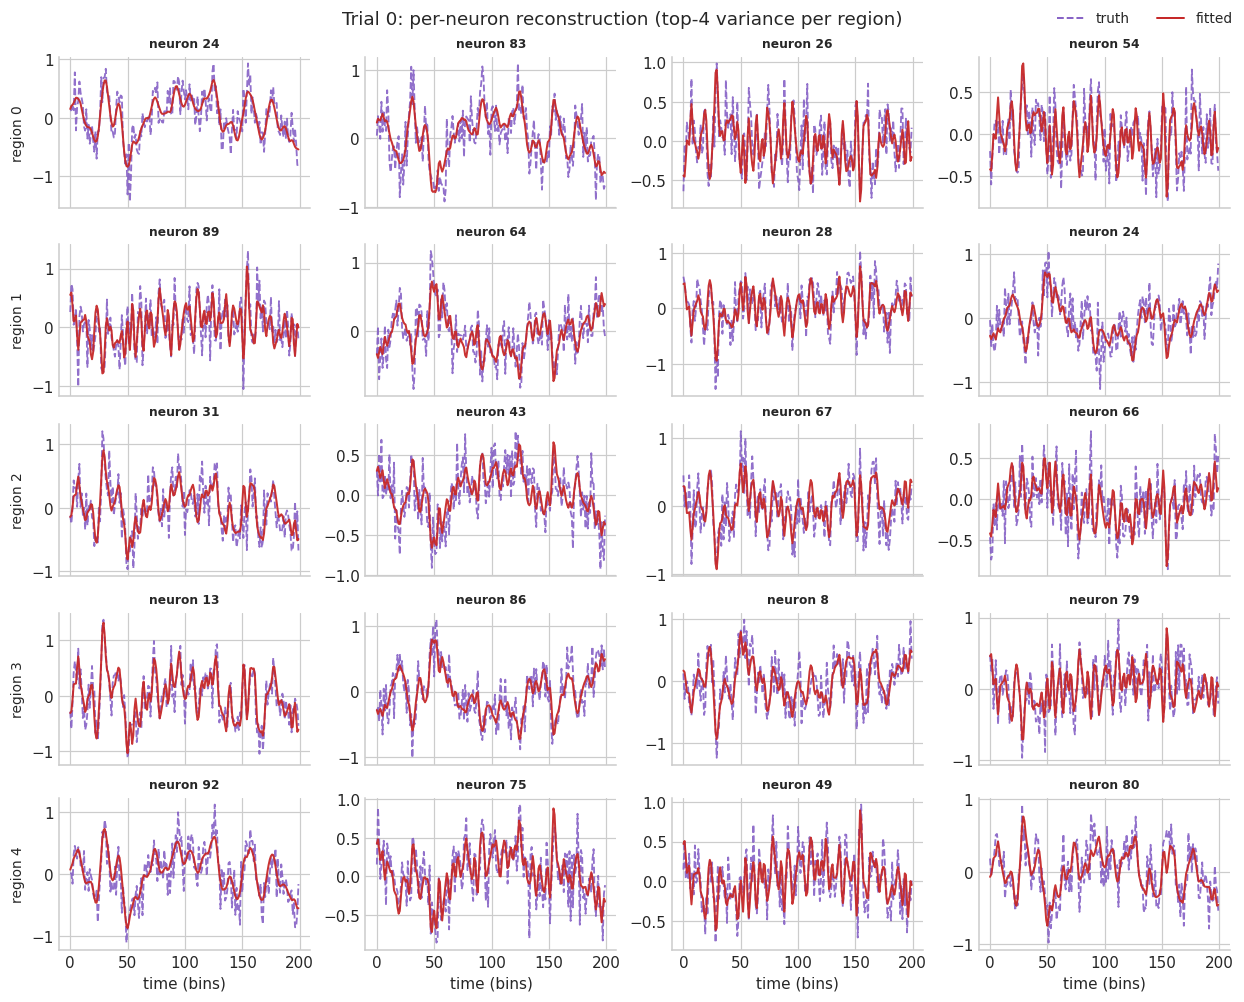

In [8]:
_ = nb.plot_trial0(
    truth["y"],
    fitted_y,
    y_dims=scenario.y_dims,
    trial=0,
    n_per_region=4,
)

## Summary

In [9]:
y_info = demo.y_recon_rmse(truth["y"], fitted_y, scenario.y_dims)
print(f"y_rmse (overall)  = {y_info['overall']:.4f}")
print(f"y_rmse per region = {[f'{v:.4f}' for v in y_info['per_region']]}")
print(f"across_perm       = {perm}")
print(f"wall time         = {result.wall_time_s:.1f}s")

y_rmse (overall)  = 0.2234
y_rmse per region = ['0.2234', '0.2232', '0.2236', '0.2232', '0.2234']
across_perm       = (1, 0)
wall time         = 285.3s
